In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import re
import numpy as np
import pandas as pd
import re
import gc
import datetime as _dt
import pyarrow.parquet as pq
from collections import defaultdict
from dateutil.relativedelta import relativedelta
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.metrics import precision_recall_curve, auc

In [2]:
df = pd.read_csv('features_v3.csv')
df.head()

,user,email_external_ratio,email_suspicious_content_ratio,email_bcc_email_ratio,email_external_email_with_attachment_ratio,email_after_hours_or_weekend_ratio,email_max_zscore_emails,email_avg_emails_per_week,email_avg_size_sent_email,email_nb_email_not_main_pc_ratio,...,http_upload_ratio,http_download_ratio,http_off_hours_ratio,http_last_month_zscore,http_max_zscore_activity,http_sus_domain_ratio,http_unique_domains,http_job_search_score,users_post_departure_activity,users_pre_departure_ratio
0,AAB0162,0.307374,0.014940,0.0,0.051176,0.000000,0.0,42.513514,1.994349e+05,0.0,...,0.0,0.0,0.0000,0.0,0.0,0.0318,126,0.0699,0.0,0.000000
1,AAB0398,0.383626,0.003674,0.0,0.118079,0.056416,0.0,51.500000,3.568791e+05,0.0,...,0.0,0.0,0.0474,0.0,0.0,0.0308,248,0.0133,0.0,0.000000
2,AAC0610,0.363118,0.009506,0.0,0.132129,0.000000,0.0,14.216216,8.273392e+05,0.0,...,0.0,0.0,0.0096,0.0,0.0,0.1031,200,0.0189,0.0,0.001404
3,AAC0668,0.350562,0.007705,0.0,0.070305,0.000000,0.0,42.094595,4.068177e+05,0.0,...,0.0,0.0,0.0000,0.0,0.0,0.0342,175,0.0548,0.0,0.000000
4,AAC3270,0.258721,0.000000,0.0,0.139535,0.000000,0.0,4.648649,1.333953e+06,0.0,...,0.0,0.0,0.0000,0.0,0.0,0.0000,55,0.0045,0.0,0.000000


In [3]:
l = pd.read_csv('cert_dataset/insiders/insiders.csv')
insiders = l[l['dataset']==6.2]['user']
insiders

186    ACM2278
187    CMP2946
188    PLJ1771
189    CDE1846
190    MBG3183
Name: user, dtype: object

In [4]:
df['is_insider'] = df['user'].isin(insiders).astype(int)
df['is_insider'].value_counts()

is_insider
0    3995
1       5
Name: count, dtype: int64

In [ ]:
X = df.drop(columns='user')

s_scaler = StandardScaler()

m_scaler = MinMaxScaler()

X_scaled_s = s_scaler.fit_transform(X)

X_scaled_m = m_scaler.fit_transform(X)

model = IsolationForest(
    n_estimators=50000,
    max_samples=4000,
    max_features=1.0,
    random_state=42
)

model.fit(X_scaled_s)

IsolationForest(max_samples=4000, n_estimators=50000, random_state=42)

In [15]:
df['anomaly_score'] = -model.score_samples(X_scaled_s)

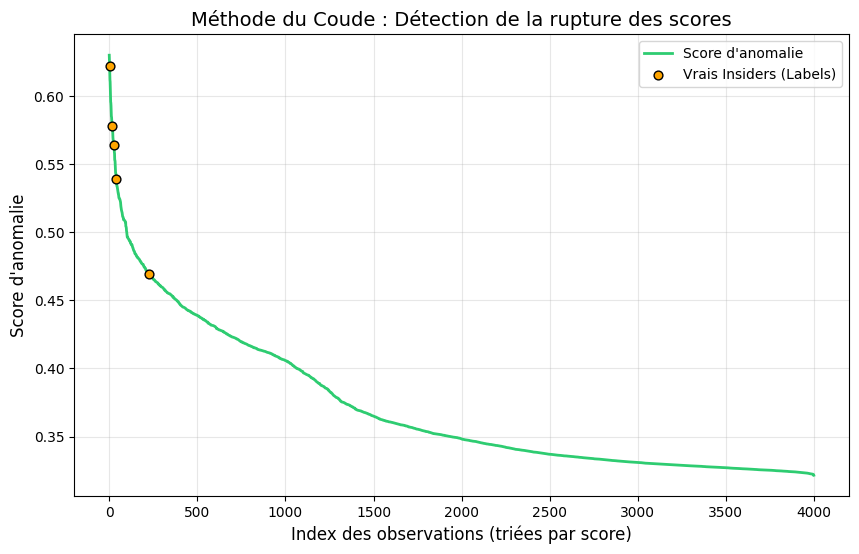

In [16]:
sorted_indices = np.argsort(df['anomaly_score'].values)[::-1]

sorted_scores = df['anomaly_score'].values[sorted_indices]

sorted_insiders = df['is_insider'].values[sorted_indices]

insider_plot_indices = np.where(sorted_insiders == 1)[0]

plt.figure(figsize=(10, 6))

plt.plot(range(len(sorted_scores)), sorted_scores, label='Score d\'anomalie', color='#2ecc71', linewidth=2)

plt.scatter(insider_plot_indices, sorted_scores[insider_plot_indices], 
            color='orange', label='Vrais Insiders (Labels)', zorder=5, s=40, edgecolors='black')

plt.title("Méthode du Coude : Détection de la rupture des scores", fontsize=14)
plt.xlabel("Index des observations (triées par score)", fontsize=12)
plt.ylabel("Score d'anomalie", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

plt.show()